In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [17]:
iris = load_iris()
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target_names[iris.target]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [20]:
df = df[df['species']!=0][['sepal width (cm)','petal length (cm)','species']]

In [22]:
df.head()

,sepal width (cm),petal length (cm),species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt


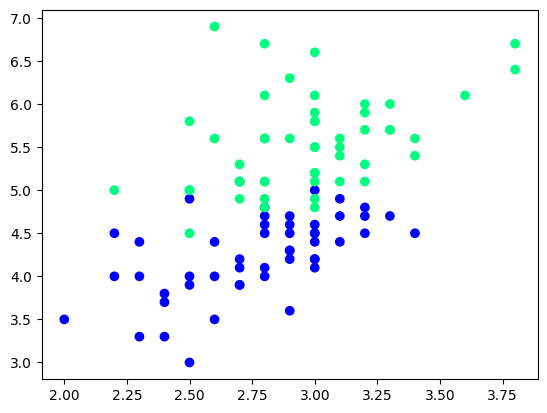

In [24]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['species'],cmap='winter')

In [25]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal width (cm),petal length (cm),species
65,3.1,4.4,1
53,2.3,4.0,1
64,2.9,3.6,1
75,3.0,4.4,1
80,2.4,3.8,1
86,3.1,4.7,1
76,2.8,4.8,1
57,2.4,3.3,1
97,2.9,4.3,1
81,2.4,3.7,1


In [26]:
# taking only 10 rows for training
df = df.sample(100) # shuffled dataset
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [27]:
df_train

,sepal width (cm),petal length (cm),species
58,2.9,4.6,1
123,2.7,4.9,2
77,3.0,5.0,1
120,3.2,5.7,2
67,2.7,4.1,1
90,2.6,4.4,1
104,3.0,5.8,2
122,2.8,6.7,2
129,3.0,5.8,2
86,3.1,4.7,1


In [28]:
df_val

,sepal width (cm),petal length (cm),species
117,3.8,6.7,2
139,3.1,5.4,2
110,3.2,5.1,2
83,2.7,5.1,1
81,2.4,3.7,1


In [29]:
df_test

,sepal width (cm),petal length (cm),species
111,2.7,5.3,2
78,2.9,4.5,1
50,3.2,4.7,1
56,3.3,4.7,1
76,2.8,4.8,1


In [30]:
X_test = df_val.iloc[:,0:2].values
Y_test = df_val.iloc[:,-1].values

In [38]:
Y_test

array([2, 2, 2, 1, 1])

In [39]:
def evaluate(clf, X,y):
  clf.fit(X,y)
  plot_tree(clf)
  plt.show()
  plot_decision_regions(X.values, y.values, clf=clf, legend=2)
  y_pred = clf.predict(X_test)
  print(accuracy_score(Y_test,y_pred))

# Case1 : bagging

In [40]:
# data for tree 1
df_bag = df_train.sample(8, replace=True) # one row can come in multiple times through this dataset


X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
58,2.9,4.6,1
123,2.7,4.9,2
122,2.8,6.7,2
123,2.7,4.9,2
90,2.6,4.4,1
123,2.7,4.9,2
67,2.7,4.1,1
122,2.8,6.7,2


In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [42]:
dt_bag1 = DecisionTreeClassifier()

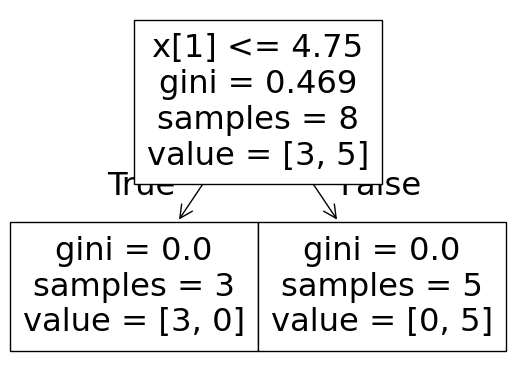

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


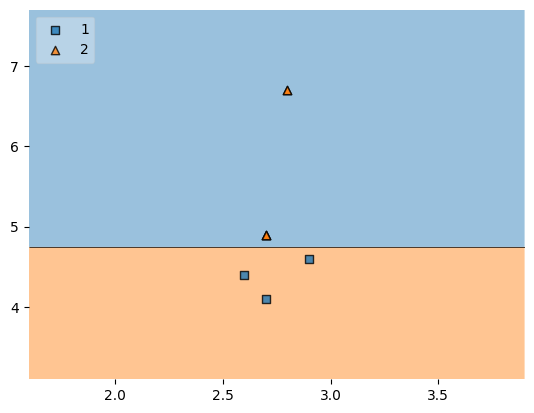

In [43]:
evaluate(dt_bag1,X,y)

In [44]:
# data for tree 2
df_bag = df_train.sample(8, replace=True)

# fetch X and y
X= df_bag.iloc[:,0:2]
y =df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),species
123,2.7,4.9,2
77,3.0,5.0,1
58,2.9,4.6,1
104,3.0,5.8,2
104,3.0,5.8,2
129,3.0,5.8,2
129,3.0,5.8,2
86,3.1,4.7,1


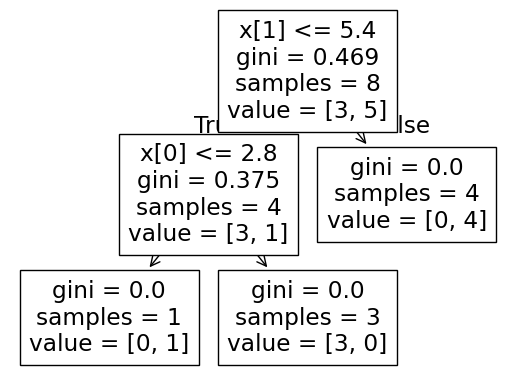

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.2


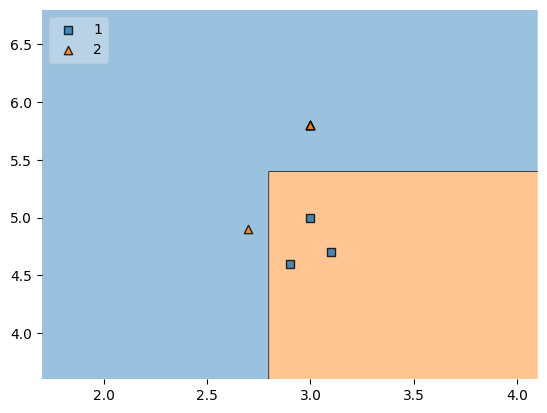

In [45]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [46]:
# data for tree 3
df_bag = df_train.sample(8, replace=True)

# fetch X and y
X= df_bag.iloc[:,0:2]
y =df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),species
90,2.6,4.4,1
123,2.7,4.9,2
120,3.2,5.7,2
67,2.7,4.1,1
123,2.7,4.9,2
77,3.0,5.0,1
120,3.2,5.7,2
104,3.0,5.8,2


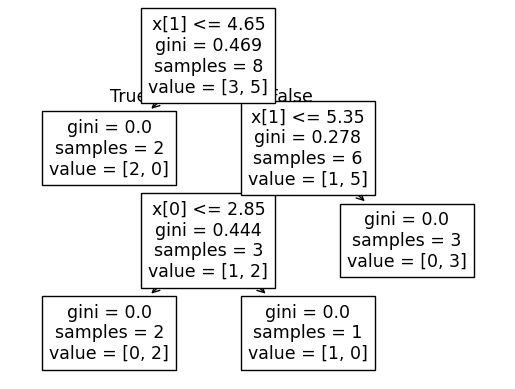

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


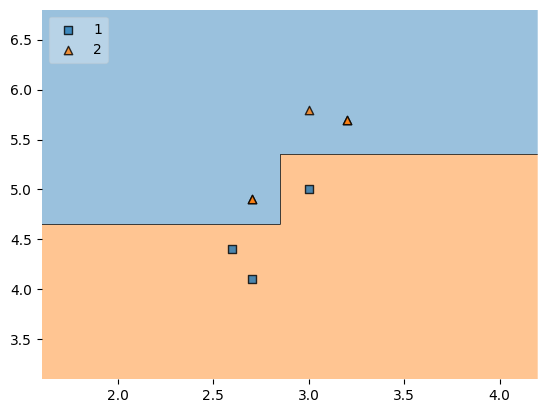

In [47]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

Predict

In [48]:
df_test

,sepal width (cm),petal length (cm),species
111,2.7,5.3,2
78,2.9,4.5,1
50,3.2,4.7,1
56,3.3,4.7,1
76,2.8,4.8,1


In [49]:
print("predictor 1", dt_bag1.predict(np.array([2.7,5.3]).reshape(1,2)))
print("predictor 2", dt_bag2.predict(np.array([2.7,5.3]).reshape(1,2)))
print("predictor 3", dt_bag3.predict(np.array([2.7,5.3]).reshape(1,2)))

predictor 1 [2]
predictor 2 [2]
predictor 3 [2]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Pasting

In [50]:
# row sampling without replacement
df_train

,sepal width (cm),petal length (cm),species
58,2.9,4.6,1
123,2.7,4.9,2
77,3.0,5.0,1
120,3.2,5.7,2
67,2.7,4.1,1
90,2.6,4.4,1
104,3.0,5.8,2
122,2.8,6.7,2
129,3.0,5.8,2
86,3.1,4.7,1


In [51]:
df_train.sample(8)

,sepal width (cm),petal length (cm),species
90,2.6,4.4,1
67,2.7,4.1,1
123,2.7,4.9,2
58,2.9,4.6,1
120,3.2,5.7,2
77,3.0,5.0,1
129,3.0,5.8,2
86,3.1,4.7,1


Random Subspaces

In [54]:
df1 = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df1["species"] = iris.target_names[iris.target]

df1 = df1.sample(10)
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
144,6.7,3.3,5.7,2.5,virginica
35,5.0,3.2,1.2,0.2,setosa
100,6.3,3.3,6.0,2.5,virginica
69,5.6,2.5,3.9,1.1,versicolor
125,7.2,3.2,6.0,1.8,virginica
24,4.8,3.4,1.9,0.2,setosa
137,6.4,3.1,5.5,1.8,virginica
4,5.0,3.6,1.4,0.2,setosa
16,5.4,3.9,1.3,0.4,setosa
74,6.4,2.9,4.3,1.3,versicolor


In [55]:
df1.sample(2, replace=True, axis=1)

,sepal width (cm),petal width (cm)
144,3.3,2.5
35,3.2,0.2
100,3.3,2.5
69,2.5,1.1
125,3.2,1.8
24,3.4,0.2
137,3.1,1.8
4,3.6,0.2
16,3.9,0.4
74,2.9,1.3


Random Patches

In [56]:
df1.sample(8, replace=True).sample(2, replace=True, axis=1)

,petal width (cm),species
4,0.2,setosa
69,1.1,versicolor
125,1.8,virginica
24,0.2,setosa
69,1.1,versicolor
4,0.2,setosa
74,1.3,versicolor
16,0.4,setosa
